## DLA CODE OF CONDUCT V2.0

This Code of Conduct defines the principles governing ethical, transparent, and responsible use of Large Language Models (LLMs), online resources, and peer collaboration in the Deep Learning Applications laboratories. This version of the Code of Conduct was refined via a brainstorming session with **ChatGPT Version 5.2** and subsequently adapted to reflect the specific requirements and values of the DLA laboratories. In that spirit, this Code itself models the transparency it expects from you.

***Our goal is not to restrict innovation, but to ensure integrity, accountability, and genuine learning.***

### 1. Transparency in the Use of LLMs and AI Tools

The use of LLMs and AI-assisted tools is permitted — *but it must be transparent*.

* **Explicit Disclosure:** Clearly state if and how LLMs (e.g., ChatGPT, Copilot, Claude, etc.) were used. This includes code generation, debugging, data analysis, experiment design, report writing, or conceptual clarification.
* **Description of Contribution:** Briefly describe what the tool contributed and how you modified, verified, or extended its output.
* **Acknowledgment of Limitations:** Recognize that LLM outputs may contain errors, biases, or non-optimal solutions. You are responsible for verifying correctness, appropriateness, and academic integrity.

***Using AI does not reduce your responsibility for the final result.***

### 2. Proper Attribution and Documentation

Deep learning builds on existing work — responsibly.

* **Attribution:** Properly cite all external resources, including: Code snippets, Tutorials, Documentation, Datasets, Pretrained models, Research papers, and AI-generated content.
* **Reproducibility:** Clearly document tools, libraries, model versions, hyperparameters, and experimental setups so that your work can be reproduced.
* **Clarity of Modifications:** If you adapt external code, explicitly indicate what you changed and why.

***Transparency is a sign of scientific maturity — not weakness.***

### 3. Collaboration and Individual Responsibility

Discussion is encouraged. Copying is not.

* **Collaborative Learning:** You are encouraged to discuss concepts, debugging strategies, and approaches with classmates.
* **Individual Submission:** Your submitted solution must reflect your own understanding and implementation.
* **No Direct Sharing of Solutions:** Do not share complete solutions, trained models, or reports. Do not submit another person's work — or AI-generated work — as your own without meaningful engagement and proper disclosure.

***If you cannot explain your submission, it is not your submission.***

### 4. Accountability and Academic Integrity

You are responsible for everything you submit. Failure to comply with these guidelines may result in review by the course examination commission and can lead to disciplinary measures in accordance with university regulations.

***Integrity is part of your training as a machine learning practitioner.***

### 5. The Spirit of This Code of Conduct

This course prepares you to work in a field where:

* Reproducibility matters
* Ethical considerations matter
* Transparency matters
* Responsible AI use matters

***The purpose of this Code of Conduct is not surveillance — it is professional formation.***

### TL;DR

Use AI; Don’t let AI use you; Be transparent; Cite everything; Do your own thinking.

***If you can’t explain it, you probably shouldn’t submit it.***

---
---

## Introduction

In this first laboratory we will see a few ways to exploit and adapt pre-trained models to solve new problems. We will start first by downloading and instantiating a new dataset and establishing a stable and reproducible baseline model based on a pre-trained CNN.

---

## Exercise 1 (Warmup): Exploratory Data Analysis and a Stable Baseline

For this laboratory we will work with [The German Traffic Sign Detection Benchmark](https://benchmark.ini.rub.de/) [1]. We will begin, not with *detection*, but with a simpler traffic sign *classification* problem. This has two advantages: (1) the images are *smaller* than in the detection benchmark; and (2) a wrapper for the GTSRB dataset is conveniently included in the `torchvision` library.  

[1] Houben S, Stallkamp J, Salmen J, Schlipsing M, Igel C. Detection of traffic signs in real-world images: The German Traffic Sign Detection Benchmark. In The 2013 International Joint Conference on Neural Networks (IJCNN), 2013.

### Exercise 1.1: Exploratory Data Analysis

A good best practice to adopt in all experimental deep learning projects is thorough *exploratory data analysis*. In this exercise you should instantiate the GTSRB Dataset, inspect some images, and do some statistical analysis of the distribution of data (and metadata). A goal here is to keep an eye out for anything that might be problematic in what is to come.



In [34]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import random
import torchvision.transforms.v2 as T
from torchvision.datasets import GTSRB

device = 'cuda' if torch.cuda.is_available() else 'cpu'

transform = T.Compose([T.ToTensor()])
ds_train = GTSRB('_data/', split='train', transform=transform, download=True)
ds_test  = GTSRB('_data/', split='test', transform=transform, download=True)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [2]:
ds_train, ds_test

(Dataset GTSRB
     Number of datapoints: 26640
     Root location: _data/
     StandardTransform
 Transform: Compose(    ToTensor()),
 Dataset GTSRB
     Number of datapoints: 12630
     Root location: _data/
     StandardTransform
 Transform: Compose(    ToTensor()))

In [3]:
ds_train[0]

(tensor([[[0.2941, 0.2902, 0.3373,  ..., 0.2667, 0.2549, 0.2588],
          [0.3255, 0.3137, 0.3529,  ..., 0.2863, 0.2980, 0.3137],
          [0.3059, 0.3373, 0.3647,  ..., 0.2824, 0.2863, 0.3059],
          ...,
          [0.5216, 0.4784, 0.4392,  ..., 0.3686, 0.3804, 0.3882],
          [0.3569, 0.3569, 0.2902,  ..., 0.4039, 0.4314, 0.3765],
          [0.3333, 0.3725, 0.2392,  ..., 0.4000, 0.3882, 0.3529]],
 
         [[0.3059, 0.2980, 0.3412,  ..., 0.2941, 0.2706, 0.2627],
          [0.3294, 0.3137, 0.3490,  ..., 0.3020, 0.3059, 0.3137],
          [0.3059, 0.3333, 0.3529,  ..., 0.2902, 0.2902, 0.3059],
          ...,
          [0.5255, 0.4980, 0.4745,  ..., 0.3686, 0.3843, 0.4039],
          [0.3725, 0.3843, 0.3333,  ..., 0.3961, 0.4431, 0.4078],
          [0.3294, 0.3961, 0.2902,  ..., 0.4000, 0.4000, 0.3804]],
 
         [[0.3137, 0.3059, 0.3294,  ..., 0.2941, 0.2667, 0.2588],
          [0.3373, 0.3216, 0.3294,  ..., 0.3059, 0.2941, 0.3059],
          [0.3137, 0.3373, 0.3569,  ...,

In [4]:
ds_train[0][0].shape

torch.Size([3, 30, 29])

In [5]:
def sample_images(dataset, num_samples=100):
    indices = np.random.choice(range(len(dataset)), num_samples)
    return [dataset[idx] for idx in indices]

def plot_image_grid(image_samples, grid_size=(10, 10), figsize=(15, 20)):
    plt.figure(figsize=figsize)
    for idx, (im, cls) in enumerate(image_samples):
        plt.subplot(grid_size[0], grid_size[1], idx + 1)
        plt.imshow(im.permute(1, 2, 0))
        plt.title(f'CLS: {cls}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

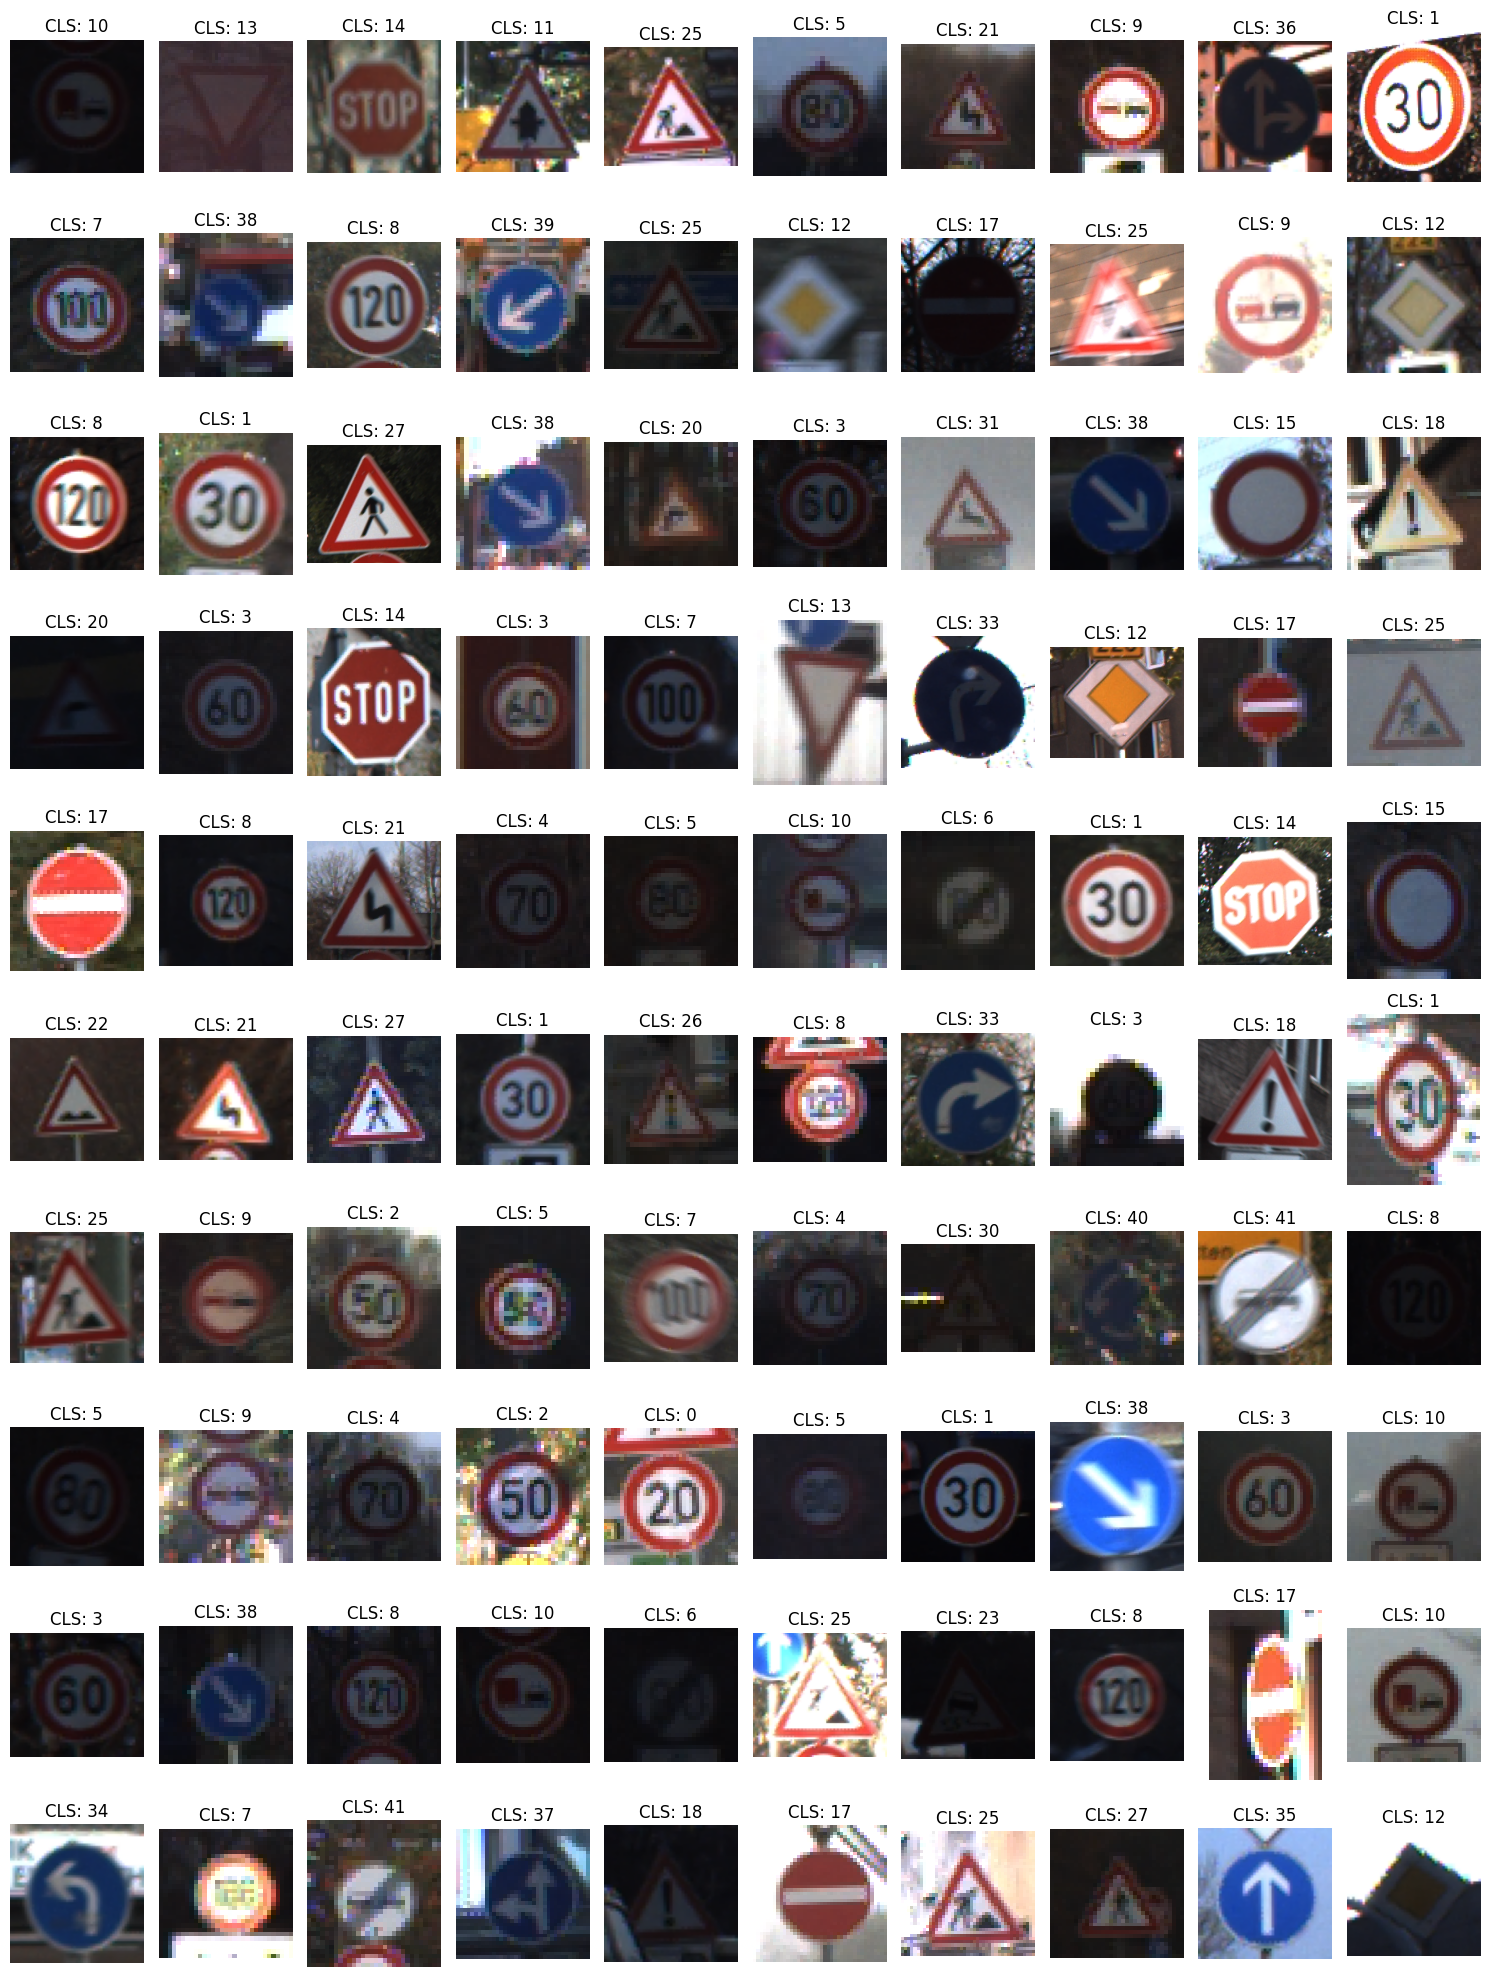

In [6]:
num_samples = 100
samples = sample_images(ds_train, num_samples)
plot_image_grid(samples)

In [7]:
import pandas as pd
df_stats = pd.DataFrame([(cls, im.shape[1], im.shape[2]) for (im, cls) in ds_train], columns=['CLS', 'HEIGHT', 'WIDTH'])
df_stats['AR'] = df_stats['WIDTH'] / df_stats['HEIGHT']

In [8]:
df_stats.describe()

,CLS,HEIGHT,WIDTH,AR
count,26640.000000,26640.000000,26640.000000,26640.000000
mean,15.887387,50.365128,50.933784,1.008718
std,12.044099,23.161523,24.373418,0.072100
min,0.000000,25.000000,25.000000,0.368132
25%,5.000000,35.000000,35.000000,0.972222
50%,12.000000,43.000000,43.000000,1.000000
75%,25.000000,58.000000,58.000000,1.044444
max,42.000000,225.000000,243.000000,1.417808


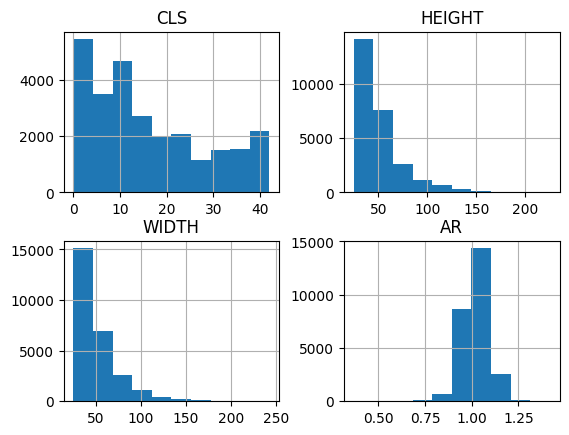

In [9]:
_ = df_stats.hist()

## Preliminary Dataset Analysis

### 1. Dataset Size
The dataset contains **26,640 images** in the training set and **12,630** images in the test set. This is a reasonably large dataset for training and should allow the model to learn meaningful visual patterns.

### 2. Image Dimensions
The images have **different resolutions**.

- **Minimum size:** 25 × 25 pixels  
- **Maximum size:** 225 × 243 pixels  
- **Average size:** approximately **50 × 51 pixels**

This means the dataset contains images with **very different scales**, from small cropped signs to larger images.

### 3. Median and Distribution
The median height and width are both **43 pixels**, meaning that most images are relatively small.
The 25th and 75th percentiles show that most images lie between **35 and 58 pixels**.
This suggests that the **majority of traffic signs are small images**, even though some larger outliers exist.

### 4. Aspect Ratio (AR)
The **average aspect ratio is approximately 1.01**, and the median is exactly **1.0**.
This means that **most images are nearly square**, which is consistent with the shape of traffic signs.
However, the aspect ratio ranges from **0.37 to 1.42**, indicating that some images are slightly rectangular due to cropping or perspective.


### 5. Class Distribution
The histogram of the class labels (CLS) shows that the dataset is **not perfectly balanced**.
Some classes appear more frequently than others.
This could potentially bias the model toward more frequent classes.

### Implications for the Model
Because images have **different resolutions and sizes**, they cannot be directly fed into a neural network.

**Therefore, before training the model, it will be necessary to apply preprocessing steps such as resizing the images to a fixed size so that they can be used as consistent inputs for our model.**

In [10]:
transform = T.Compose([T.Resize(70), T.RandomCrop((64, 64)), T.ToTensor(), T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
ds_train = GTSRB('_data/', split='train', transform=transform, download=True)
ds_test  = GTSRB('_data/', split='test', transform=transform, download=True)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


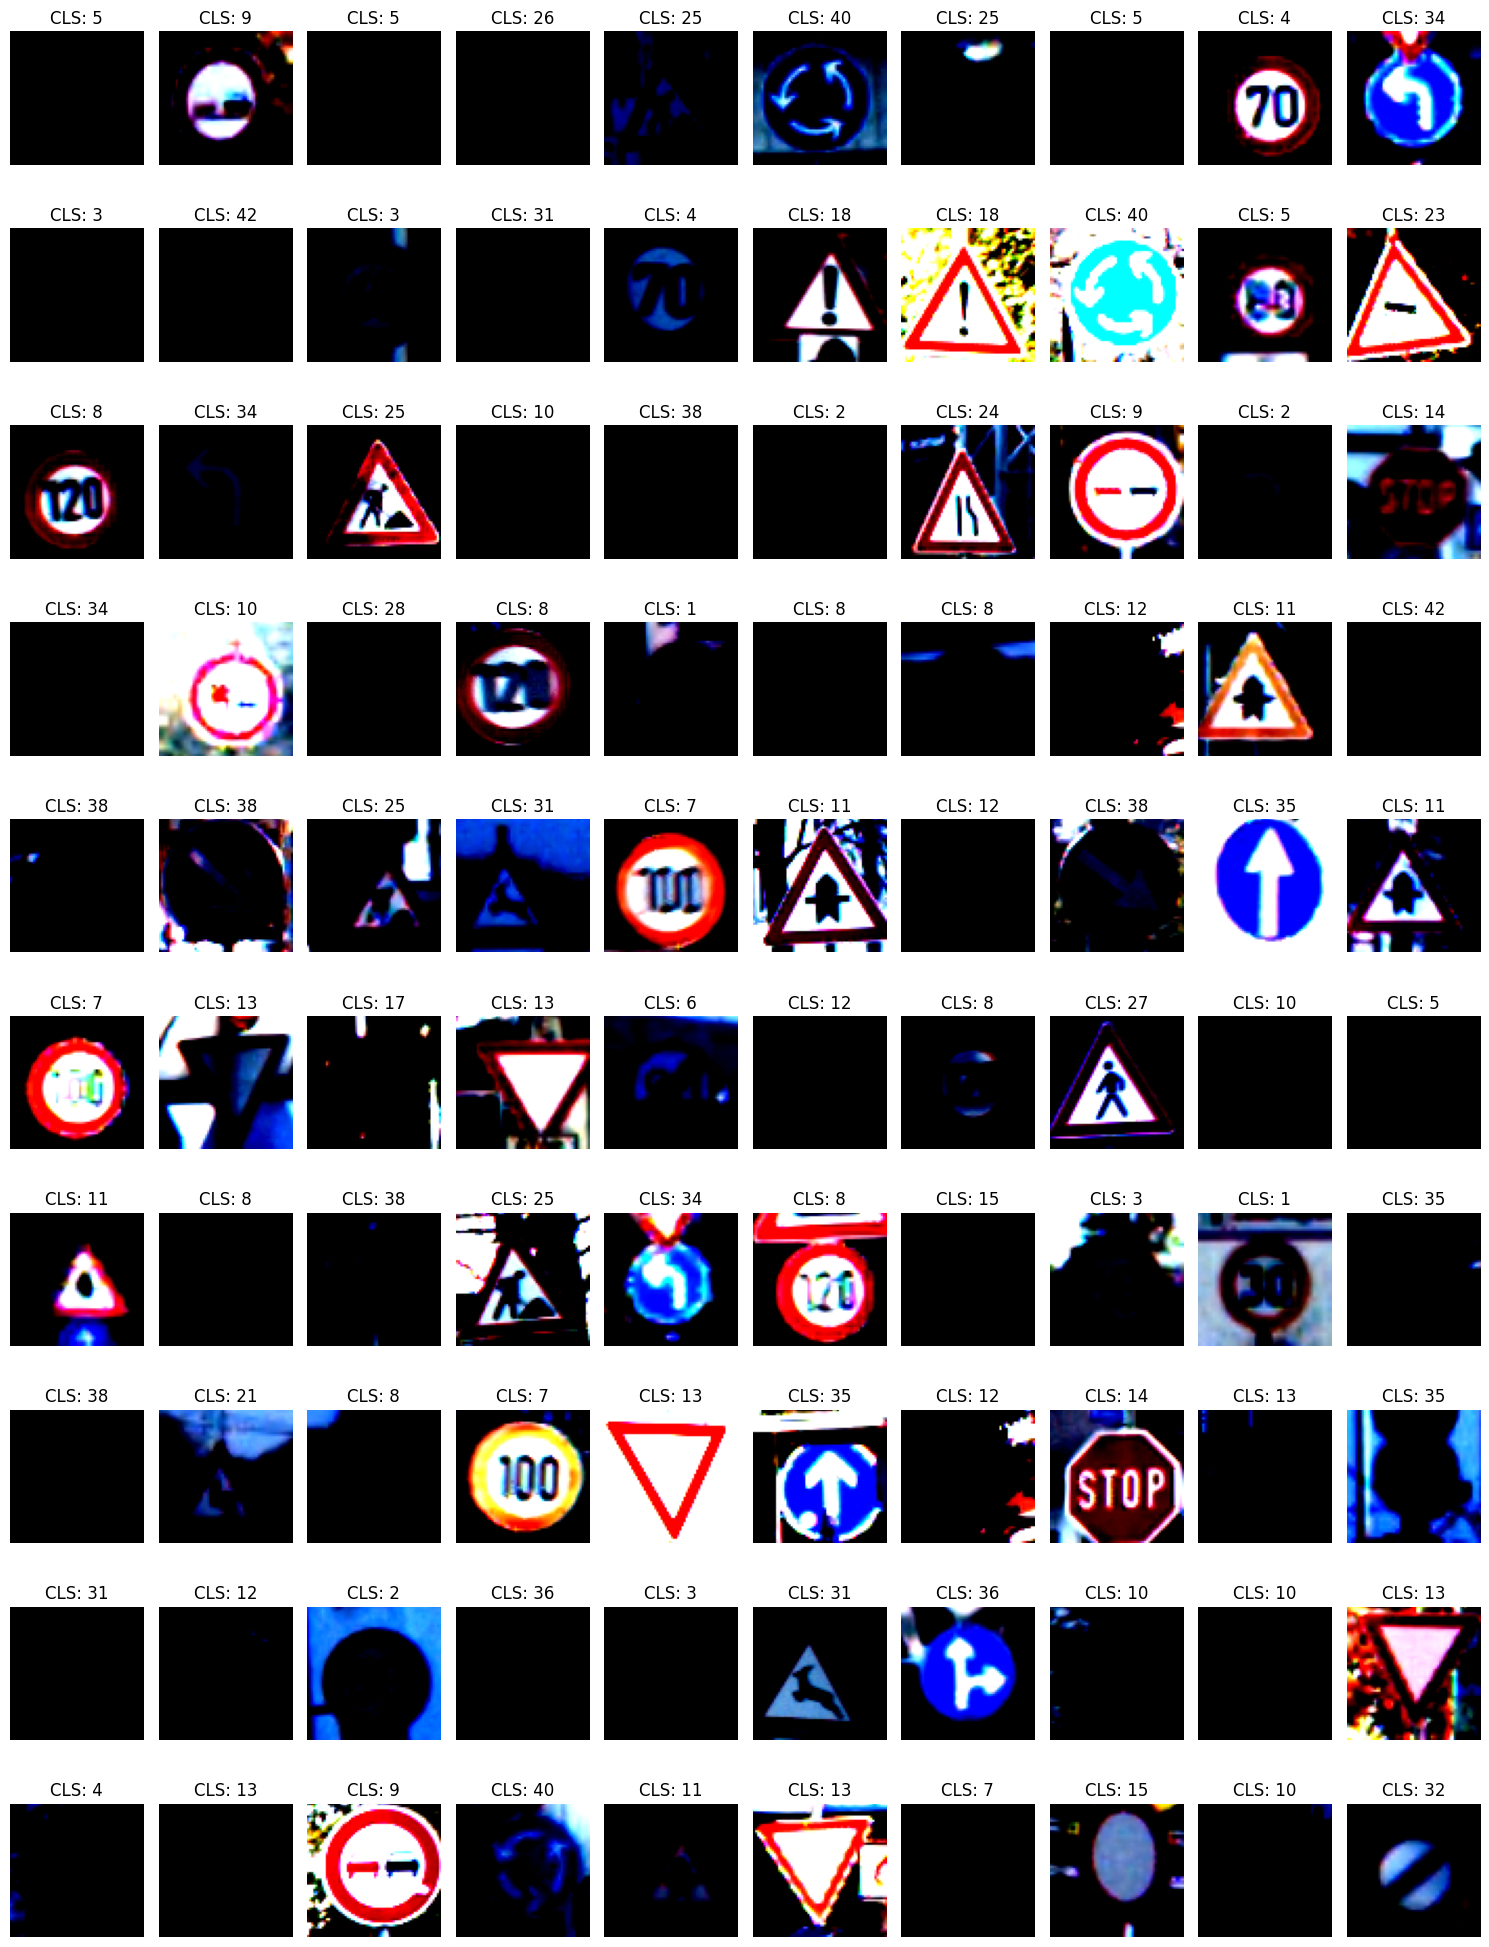

In [11]:
num_samples = 100
samples = sample_images(ds_train, num_samples)
plot_image_grid(samples)

### Final Transformation

To address the issues from the preliminary analysis, we define a **transformation pipeline** that standardizes the images before they are used by the model.

First, each image is **resized** so that its smallest side becomes **70 pixels**. This ensures that all images are large enough for the next step and reduces the variability in image sizes across the dataset.

Next, a **random crop of size 64×64** is extracted from the resized image. This guarantees that every image has the **same final dimensions**, which is required as input for a neural network. The crop location is random, so the model may see slightly different portions of the same image during training. This acts as a simple form of **data augmentation**, helping the model generalize better.

After cropping, the image is converted from a **PIL image into a PyTorch tensor** using `ToTensor()`. This step also scales pixel values from **0–255 to the range 0–1**, which is more suitable for neural network training.

Finally, the tensor is **normalized** using the standard **mean and standard deviation values from ImageNet**, which are commonly used with architectures such as **ResNet**. Normalization centers and scales the data, improving training stability and convergence.

This transformation pipeline is applied when loading both the **training dataset (`ds_train`)** and the **test dataset (`ds_test`)**, ensuring that every image goes through the same preprocessing steps before being used by the model.


---
### Exercise 1.2: A Stable and Reproducible Baseline

**TODO**: Write a description of this exercise.

In [ ]:
from torchvision.models import list_models, get_model

In [13]:
list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [14]:
from torch.utils.data import DataLoader
import torch.nn as nn

def create_dataloaders(ds_train, ds_test, batch_size=1024):
    dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True)
    dl_test = DataLoader(ds_test, batch_size=batch_size, shuffle=True)
    return dl_train, dl_test


def load_feature_extractor(device):
    model = get_model('resnet18', weights='DEFAULT')
    model.fc = nn.Identity()  # Output features instead of class scores
    model = model.to(device)
    return model


In [15]:
batch_size = 1024
dl_train, dl_test = create_dataloaders(ds_train, ds_test, batch_size)
model = load_feature_extractor(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 220MB/s]


In [16]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Data Loading and Model Setup

- **DataLoader**: Splits datasets into batches (`batch_size=1024`) and shuffles data for better generalization.
- **Pretrained ResNet18**: Loaded with ImageNet weights to reuse learned features.
- **`nn.Identity()`**: Replaces the final classifier to output feature vectors instead of class scores.
- **Device transfer**: `model.to(device)` moves the model to GPU/CPU.

**Purpose**: Use the network as a feature extractor for downstream tasks.

In [17]:
from tqdm.notebook import tqdm

def extract_features(dataloader, model, device):
    feats = []
    classes = []
    model.eval()
    for ims, cls in tqdm(dataloader):
        ims = ims.to(device)
        with torch.no_grad():
            feats.append(model(ims))
        classes.append(cls)
    feats = torch.vstack(feats).cpu()
    classes = torch.concat(classes)
    return feats, classes

In [18]:
train_feats, train_classes = extract_features(dl_train, model, device)
test_feats, test_classes = extract_features(dl_test, model, device)

  0%|          | 0/27 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

In [ ]:
train_feats.shape, train_classes.shape

(torch.Size([26640, 512]), torch.Size([26640]))

In [ ]:
test_feats.shape, test_classes.shape

(torch.Size([12630, 512]), torch.Size([12630]))

## Feature Extraction Pipeline

This code extracts feature representations from images using a pretrained model in evaluation mode.

- **`model.eval()`** ensures the network behaves deterministically (no dropout, fixed BatchNorm).
- The dataset is processed **batch by batch** using a DataLoader.

Inside the loops:
- Images are moved to the selected device (`GPU/CPU`).
- `torch.no_grad()` disables gradient computation → faster and memory-efficient.
- `model(ims)` outputs a **512-dimensional feature vector** per image (since the classifier was removed).
- Features and labels are stored in lists (efficient dynamic storage).

After processing all batches:
- `torch.vstack(feats)` combines all features into a single tensor.
- `torch.concat(classes)` merges all labels.

**Final result:**
- Training features: `(26640, 512)`
- Test features: `(12630, 512)`

Each image is now represented as a compact vector, ready for downstream tasks like classification or visualization.

In [21]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

def train_svm(train_feats, train_classes, kernel="linear"):
    model = SVC(kernel=kernel)
    model.fit(train_feats, train_classes)
    return model

def evaluate_model(model, test_feats, test_classes):
    preds = model.predict(test_feats)
    report = classification_report(test_classes, preds)
    print(report)
    return report

In [22]:
svc = train_svm(train_feats, train_classes)
evaluate_model(svc, test_feats, test_classes)

              precision    recall  f1-score   support

           0       0.25      0.35      0.29        60
           1       0.48      0.63      0.55       720
           2       0.42      0.46      0.44       750
           3       0.35      0.36      0.35       450
           4       0.59      0.54      0.56       660
           5       0.50      0.47      0.48       630
           6       0.98      0.81      0.89       150
           7       0.59      0.54      0.56       450
           8       0.48      0.36      0.42       450
           9       0.88      0.77      0.82       480
          10       0.85      0.90      0.87       660
          11       0.50      0.62      0.55       420
          12       0.94      0.98      0.96       690
          13       0.95      0.98      0.96       720
          14       0.91      0.84      0.87       270
          15       0.98      0.95      0.96       210
          16       0.86      0.85      0.86       150
          17       0.98    

'              precision    recall  f1-score   support\n\n           0       0.25      0.35      0.29        60\n           1       0.48      0.63      0.55       720\n           2       0.42      0.46      0.44       750\n           3       0.35      0.36      0.35       450\n           4       0.59      0.54      0.56       660\n           5       0.50      0.47      0.48       630\n           6       0.98      0.81      0.89       150\n           7       0.59      0.54      0.56       450\n           8       0.48      0.36      0.42       450\n           9       0.88      0.77      0.82       480\n          10       0.85      0.90      0.87       660\n          11       0.50      0.62      0.55       420\n          12       0.94      0.98      0.96       690\n          13       0.95      0.98      0.96       720\n          14       0.91      0.84      0.87       270\n          15       0.98      0.95      0.96       210\n          16       0.86      0.85      0.86       150\n       

## Conclusions

The SVM on top of ResNet18 features achieves **62% accuracy** (macro F1 = 0.55), with good performance on some classes but poor results on others, especially minority or visually similar ones. This shows that pretrained features are useful but not sufficient for all categories.

While this approach is **simple and efficient**, it is limited because the feature extractor is not adapted to the dataset and the linear SVM has limited flexibility.


---
### Exercise 1.3: A Fine-tuning Baseline

### Description of the Exercise
We fine-tune a pretrained **ResNet-18** for traffic sign classification (43 classes). The final layer is replaced, and the model is trained for 30 epochs using cross-entropy loss and Adam optimizer. Performance is evaluated using accuracy and classification metrics.


In [23]:
from sklearn.metrics import accuracy_score
import torch.nn.functional as F

# Function to train a model for a single epoch over the data loader.
def train_epoch(model, dl, opt, epoch='Unknown', device='cpu'):
    model.train()
    losses = []
    for (xs, ys) in tqdm(dl, desc=f'Training epoch {epoch}', leave=True):
        xs = xs.to(device)
        ys = ys.to(device)
        opt.zero_grad()
        logits = model(xs)
        loss = F.cross_entropy(logits, ys)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return np.mean(losses)

# Function to evaluate model over all samples in the data loader.
def evaluate_model(model, dl, device='cpu'):
    model.eval()
    predictions = []
    gts = []
    for (xs, ys) in tqdm(dl, desc='Evaluating', leave=False):
        xs = xs.to(device)
        preds = torch.argmax(model(xs), dim=1)
        gts.append(ys)
        predictions.append(preds.detach().cpu().numpy())

    # Return accuracy score and classification report.
    return (accuracy_score(np.hstack(gts), np.hstack(predictions)),
            classification_report(np.hstack(gts), np.hstack(predictions), zero_division=0, digits=3))

# Simple function to count the parameters in a model.
def count_parameters(model):
    return np.sum([p.numel() for p in model.parameters()])

In [24]:
# Load our ResNet model.
model = get_model('resnet18', weights='DEFAULT')
model.fc = nn.Linear(512, 43)
model = model.to(device)

# The training dataloader.
batch_size = 1024
dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
dl_test = DataLoader(ds_test, batch_size=batch_size, shuffle=False, num_workers=True)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  0%|          | 0/30 [00:00<?, ?it/s]

Training epoch 1:   0%|          | 0/27 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Training epoch 2:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 3:   0%|          | 0/27 [00:00<?, ?it/s]

...

Training epoch 28:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 29:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 30:   0%|          | 0/27 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0      0.951     0.650     0.772        60
           1      0.959     0.964     0.961       720
           2      0.914     0.967     0.940       750
           3      0.976     0.902     0.938       450
           4      0.937     0.970     0.953       660
           5      0.891     0.946     0.918       630
           6      0.987     1.000     0.993       150
           7      0.969     0.984     0.977       450
           8      0.938     0.900     0.918       450
           9      0.975     0.908     0.941       480
          10      0.980     0.989     0.985       660
          11      0.932     0.917     0.924       420
          12      0.993     0.996     0.994       690
          13      0.982     0.997     0.990       720
          14      0.938     0.959     0.949       270
          15      0.995     0.995     0.995       210
          16      0.924     0.967     0.945       150
          17      0.977    

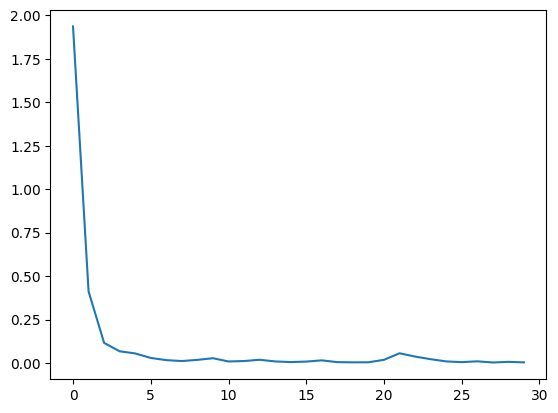

In [25]:
epochs = 30
lr = 0.0001
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

losses = []
for epoch in tqdm(range(epochs)):
    losses.append(train_epoch(model, dl_train, optimizer, epoch+1, device=device))

plt.plot(losses)
(accuracy, cls_report) = evaluate_model(model, dl_test, device=device)
print(cls_report)

### Conclusions
- Achieves **95.2% accuracy**, showing strong performance.
- Fast loss convergence due to **transfer learning**.
- Overall, the model generalizes well but could improve with augmentation or better balancing.

---
---
## Exercise 2: Pipeline Consolidation

Consolidate your implementation. When building applications based asd on Deep Learning, you will inevitably need to run many, many experiments. So, it is *always* a good idea to engineer a reproducible pipeline that allows you to run (and re-run) experiments with different hyperparameters. In this exercise you should do exactly this: engineer a deep learning pipeline that encapsulates (at least) training and evaluation so that you can easily and reproducibly run multiple experiments and compare the results.

Some things to think about when engineering this pipeline:
- **Model and Loss (and maybe Optimizer) Abstraction**: An important variable in training deep models is the model (obviously), the loss (somewhat less obvious), and the optimizer (less obvious) used during training. Your pipeline should probably be able to adapt to these changing configurations.
- **Configuration management**: Instead of global variables specializing each cell, thread a configuration object through your code (or use a singleton). If you are planning to use an IDE and not this notebook for the lab, you might consider using a configuration management library like [OmegaConf](https://omegaconf.readthedocs.io/en/2.3_branch/) which will help instrument your code so that you can pass configuration overrides via command line arguments.
- **Logging**: You will invariably need to run and compare multiple experiments. Instrument your code for monitoring training. Good options are [Tensorboard](https://docs.pytorch.org/tutorials/recipes/recipes/tensorboard_with_pytorch.html) or [Weights and Biases (WandB)](https://wandb.ai/site/). My PhD students seem to overwhelmingly prefer Weights and Biases. The configuration parameters should be used to facilitate distinguishing and comparing multiple runs with multiple hyperparameters.

In [ ]:
config = {
    "model": {
        "name": "resnet18",
        "num_classes": 43,
        "pretrained": True,
        "freeze_backbone": False
    },
    "training": {
        "epochs": 10,
        "batch_size": 1024,
        "lr": 1e-3,
        "optimizer": "adam",
        "loss": "cross_entropy",
        "weight_decay": 0.0
    },
    "data": {
        "num_workers": 2
    },
    "system": {
        "seed": 42,
        "device": "cuda"
    },
    "logging": {
        "run_name": "baseline_resnet18"
    }
}

In [ ]:
def build_model(config):
    model_name = config["model"]["name"]
    num_classes = config["model"]["num_classes"]
    pretrained = config["model"]["pretrained"]
    freeze_backbone = config["model"]["freeze_backbone"]

    if model_name == "resnet18":
        weights = "DEFAULT" if pretrained else None
        model = get_model("resnet18", weights=weights)
    else:
        raise ValueError(f"Unsupported model: {model_name}")

    # Freeze backbone if requested
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace classifier
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    # Ensure final classifier is trainable
    for param in model.fc.parameters():
        param.requires_grad = True

    model = model.to(config["system"]["device"])
    return model

In [ ]:
def build_loss(config):
    loss_name = config["training"]["loss"]

    if loss_name == "cross_entropy":
        return nn.CrossEntropyLoss()
    else:
        raise ValueError(f"Unsupported loss: {loss_name}")
    
def build_optimizer(config, model):
    optimizer_name = config["training"]["optimizer"]
    lr = config["training"]["lr"]
    weight_decay = config["training"]["weight_decay"]

    trainable_params = filter(lambda p: p.requires_grad, model.parameters())

    if optimizer_name == "adam":
        return torch.optim.Adam(trainable_params, lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "sgd":
        momentum = config["training"].get("momentum", 0.9)
        return torch.optim.SGD(trainable_params, lr=lr, momentum=momentum, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")
    
def train_one_epoch(model, dl, criterion, optimizer, epoch='Unknown', device = "cuda"):
    model.train()
    losses = []
    predictions = []
    gts = []

    for xs, ys in tqdm(dl, desc=f'Training epoch {epoch}', leave=True):
        xs = xs.to(device)
        ys = ys.to(device)

        optimizer.zero_grad()
        logits = model(xs)
        loss = criterion(logits, ys)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        preds = torch.argmax(logits, dim=1)
        predictions.append(preds.detach().cpu().numpy())
        gts.append(ys.detach().cpu().numpy())

    avg_loss = np.mean(losses)
    acc = accuracy_score(np.hstack(gts), np.hstack(predictions))

    return avg_loss, acc

def evaluate(model, dl, criterion, device = "cuda"):
    model.eval()
    losses = []
    predictions = []
    gts = []
    with torch.no_grad():
        for xs, ys in tqdm(dl, desc='Evaluating', leave=False):
            xs = xs.to(device)
            ys = ys.to(device)

            logits = model(xs)
            loss = criterion(logits, ys)

            losses.append(loss.item())

            preds = torch.argmax(logits, dim=1)
            predictions.append(preds.detach().cpu().numpy())
            gts.append(ys.detach().cpu().numpy())

    avg_loss = np.mean(losses)
    acc = accuracy_score(np.hstack(gts), np.hstack(predictions))
    report = classification_report(
        np.hstack(gts),
        np.hstack(predictions),
        zero_division=0,
        digits=3
    )

    return avg_loss, acc, report

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def count_parameters(model):
    return np.sum([p.numel() for p in model.parameters()])

In [ ]:
def run_experiment(config, dl_train, dl_test):
    set_seed(config["system"]["seed"])
    device = config["system"]["device"]

    model = build_model(config)
    criterion = build_loss(config)
    optimizer = build_optimizer(config, model)

    print(f"\nRunning experiment: {config['logging']['run_name']}")
    print(f"Model parameters: {count_parameters(model):,}")

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_val_acc = 0.0
    best_epoch = 0
    val_report = None

    for epoch in range(config["training"]["epochs"]):
        train_loss, train_acc = train_one_epoch(
            model, dl_train, criterion, optimizer, epoch=epoch + 1, device=device
        )

        val_loss, val_acc, val_report = evaluate(
            model, dl_test, criterion, device=device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1

        print(f"\nEpoch {epoch+1}/{config['training']['epochs']}")
        print(f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
        print(f"Val   loss: {val_loss:.4f} | Val   acc: {val_acc:.4f}")

    print("\nTraining finished")
    print(f"Best val accuracy: {best_val_acc:.4f} at epoch {best_epoch}")

    return {
        "model": model,
        "history": history,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "final_report": val_report,
    }

In [35]:
results = run_experiment(config, dl_train, dl_test)


Running experiment: baseline_resnet18
Model parameters: 11,198,571


Training epoch 1:   0%|          | 0/27 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]


Epoch 1/10
Train loss: 0.5994 | Train acc: 0.8352
Val   loss: 0.6935 | Val   acc: 0.8530


...


Epoch 9/10
Train loss: 0.0941 | Train acc: 0.9812
Val   loss: 0.4141 | Val   acc: 0.8959


Training epoch 10:   0%|          | 0/27 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]


Epoch 10/10
Train loss: 0.0624 | Train acc: 0.9847
Val   loss: 0.4051 | Val   acc: 0.8919

Training finished
Best val accuracy: 0.9645 at epoch 4


In [ ]:
# Your code here.

# Or, even better: Consolidate your code in separate Python modules that you can
# import here and then REUSE.


---
---
## Exercise 3: Choose your Own Adventure

As promised, you should choose **one** of the following exercises to work. Well, at *least* one. If you want to do them all, that is also OK!

---
### Exercise 3.1 (Easy): Improving Fine-tuning Performance

In this exercise you are asked to iterate on the fine-tuning experiment performed in Exercise 1.3 in order to squeeze the best performance possible out of the model.

What can we do:
- Use a more powerful model?
- More aggressive data augmentation?
- Selective layer training?
- Something else?

**Why choose this exercise?** To hone your skills at incrementally improving fined-tuned model performance via a sequence of (carefully monitored) experiments.

In [ ]:
# Your code here.


---
### Exercise 3.2: Retrieval as Training-free Classification (a bit harder)

In this exercise you will treat the problem of classifying road signs as a type of retrieval problem. By doing so, will will avoid the need to perform extensive fine-tuning of our model and will instead count of the good *representations* provided by massively pretrained models.

How, you ask? In this exercise you should treat the training set as a *gallery* of indexed image descriptors and the test set as a set of *query* descriptors. You could proceed in this way:

1. **Implement** a generic *feature extraction* function that, given a model and a dataloader, will extract the feature representations of all images in the dataloader. You should make this function generic because you will of course want to try *multiple* pretrained backbones in order to pick the best one.
2. **Implement** a function to *query* the gallery using all extracted extracted from the test set. The results of this should be a *ranking* of all gallery images in terms of similarity with each test image. You should think carefully about how to compute this *similarity* score and how to compute it efficiently.
3. **Evaluate** the retrieval performance on each of the 43 classes in the GTSRB dataset using the similarity scores. This could be done using precision recall curves, average precision/recall, or other metrics.

Wait, this isn't a classifier... Well, no. But, if you use the above *pipeline* to select the best feature extraction pipeline, you can then implement a **Nearest-Mean Classifier (NMC)**: compute the *mean* feature representation of all training images for each class and *classify* test images based on which mean is **nearest** to it.

**Why choose this exercise?** To learn how to make the most out of pretrained feature extraction backbones, how to evaluate different types of learning systems (retrieval in this case), and to familiarize yourself with similarity-based classification which is extensively used in multimodal models like CLIP.


---
### Exercise 3.3: *Detecting* Traffic Signs (hardest)

In this exercise you will see if you can take your pretrained *classification* backbone and turn it into a *detector*. We will need another dataset for this -- one with *full image frames* instead of cropped sign images. Luckily, this dataset is available on [Hugging Face](https://huggingface.co/datasets/keremberke/german-traffic-sign-detection) (see below for how to access it).

For this exercise, you could:
1. Start from an available Faster-RCNN model from `torchvision` and *replace* the feature extraction backbone with your ResNet fine-tuned on GTRSB.
2. This *stitched-together* network should do an OK-ish job already of detecting at least *some* traffic signs. See how it performs on some of the images from the GTRSB Detection dataset. Implement a simple function to visualize detections superimposed over the original image. Compute some detection metrics (accuracy @ IoU=0.5, for example).
3. If you're feeling ambitious, you could also *fine-tune* the resulting model to improve detection performance.

**NOTE**: The pretrained Faster-RCNN models in `torchvision` are all based on ResNet-50, so this exercise will likely be much less painful if you use a ResNet-50 from the very start.

**Also Note**: To use the **GTRSB Detection Dataset** you should use the `datasets` package from Hugging Face (version 3.X):

     # If using uv.
     uv add datasets==3

or

     # If using Anaconda
     conda install -c conda-forge datasets==3

In [ ]:
from datasets import load_dataset

# Download the full detection dataset from the Hugging Face Hub.
# You will want to spend some time studying the organization of this dataset.
ds = load_dataset("keremberke/german-traffic-sign-detection", name="full")

# Your code here.

RuntimeError: Dataset scripts are no longer supported, but found german-traffic-sign-detection.py

---
---